# Capstone — Extended BNMF Component Analysis

A deep-dive companion to `capstone_notebook.ipynb`. Loads the cached Bayesian-NMF
outputs (`results/bnmf/`) and the AST embedding features, and produces
additional, **previously missing** visualisations to better interpret what the
discovered sound components are.

**New visualisations added here:**

1. BIC curve with annotated values
2. Stacked-bar category composition (Top-50 clips per component)
3. Component co-activation correlation matrix
4. Weight-space similarity matrix (how similar components are in 768-d AST space)
5. Heatmap of each component's strongest AST feature dimensions
6. Per-component entropy / purity bar chart
7. Confusion matrix — dominant BNMF component vs ground-truth category
8. TF-IDF top words from top-captions per component
9. t-SNE coloured by activation **strength** for each component (small-multiples)
10. Per-component activation strip plot (top-100 clip rankings)

All figures are also saved to `results/figures/extra/` for re-use in the report.


## 1. Setup — imports, load cached outputs

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import entropy as scipy_entropy

import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "scripts":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
FEAT_DIR = DATA_DIR / "features"
BNMF_DIR = PROJECT_DIR / "results" / "bnmf"
FIG_DIR  = PROJECT_DIR / "results" / "figures" / "extra"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_DIR}")
print(f"Figures will be saved to: {FIG_DIR}")


Project root: C:\Users\wdy\OneDrive - UC San Diego\桌面\美国doc\capstone_project
Figures will be saved to: C:\Users\wdy\OneDrive - UC San Diego\桌面\美国doc\capstone_project\results\figures\extra


In [2]:
# Load BNMF cached outputs
cons_resp    = np.load(BNMF_DIR / "consensus_response.npy")   # (1442, K)
cons_weights = np.load(BNMF_DIR / "consensus_weights.npy")    # (K, 768)
bics         = np.load(BNMF_DIR / "bics.npy")
ast_feats    = np.load(FEAT_DIR / "ast_embeddings.npy")
labeled      = pd.read_csv(DATA_DIR / "audiocaps_labeled.csv")

K = cons_resp.shape[1]
N = cons_resp.shape[0]
labels_cat    = labeled["category"].values[:N]
labels_speech = labeled["is_speech"].values[:N]
captions      = labeled["answer"].values[:N]

# Component naming derived from inspection of top captions (Section 7 of main notebook)
COMP_LABELS = {
    1: "Railway",      2: "Machinery",    3: "Water/Rain",
    4: "Crowd noise",  5: "Impact sounds",6: "Infant/Animal",
    7: "Female speech",8: "Weather/Waves",9: "Outdoor mixed", 10: "Vehicles",
}
COMP_NAMES = [f"C{i+1}: {COMP_LABELS.get(i+1, '?')}" for i in range(K)]
BNMF_COLORS = [plt.cm.tab10(i / 10) for i in range(K)]
CAT_COLORS = {"speech": "#E74C3C", "music": "#3498DB", "nature": "#2ECC71",
              "environment": "#F39C12", "animal": "#9B59B6"}
ALL_CATS = ["speech", "environment", "nature", "animal", "music"]
SEARCH_LIST = list(range(5, 26, 5))

print(f"BNMF: K = {K} components,  N = {N} clips")
print(f"AST embedding dim: {ast_feats.shape[1]}")
print(f"BIC values (K = {SEARCH_LIST}): {[f'{b:.3e}' for b in bics]}")


BNMF: K = 10 components,  N = 1442 clips
AST embedding dim: 768
BIC values (K = [5, 10, 15, 20, 25]): ['7.244e+05', '7.166e+05', '7.352e+05', '7.833e+05', '8.538e+05']


## 2. BIC curve with all values annotated

A more readable version of the K-selection plot from the main notebook — every
candidate K gets its BIC value annotated, and the optimal point is highlighted.


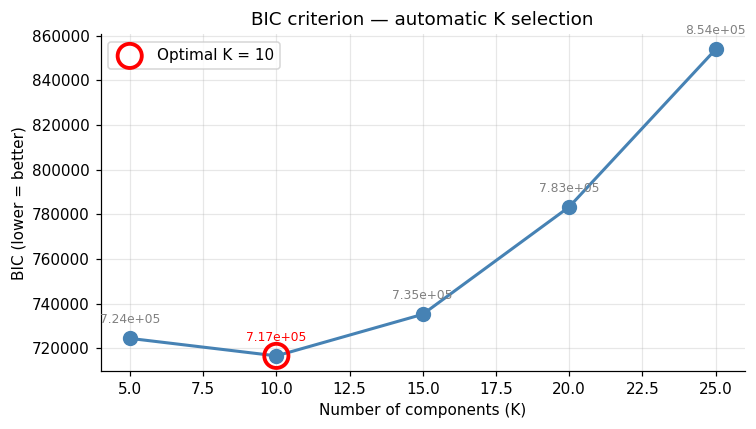

In [3]:
optimal_k = SEARCH_LIST[int(np.argmin(bics))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(SEARCH_LIST, bics, "o-", color="steelblue", linewidth=2, markersize=9, zorder=3)
for k, b in zip(SEARCH_LIST, bics):
    ax.annotate(f"{b:.2e}", (k, b), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8,
                color="red" if k == optimal_k else "gray")
ax.scatter([optimal_k], [bics[SEARCH_LIST.index(optimal_k)]],
           s=250, facecolors="none", edgecolors="red", linewidth=2.5,
           label=f"Optimal K = {optimal_k}", zorder=4)
ax.set_xlabel("Number of components (K)")
ax.set_ylabel("BIC (lower = better)")
ax.set_title("BIC criterion — automatic K selection")
ax.legend()
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "bic_curve_annotated.png", bbox_inches="tight")
plt.show()


## 3. Stacked-bar — category composition of top-50 per component

Instead of K separate bar charts (as in the script's output), a single stacked
bar makes it immediately obvious which components are "pure" (one category
dominates) and which are mixed.


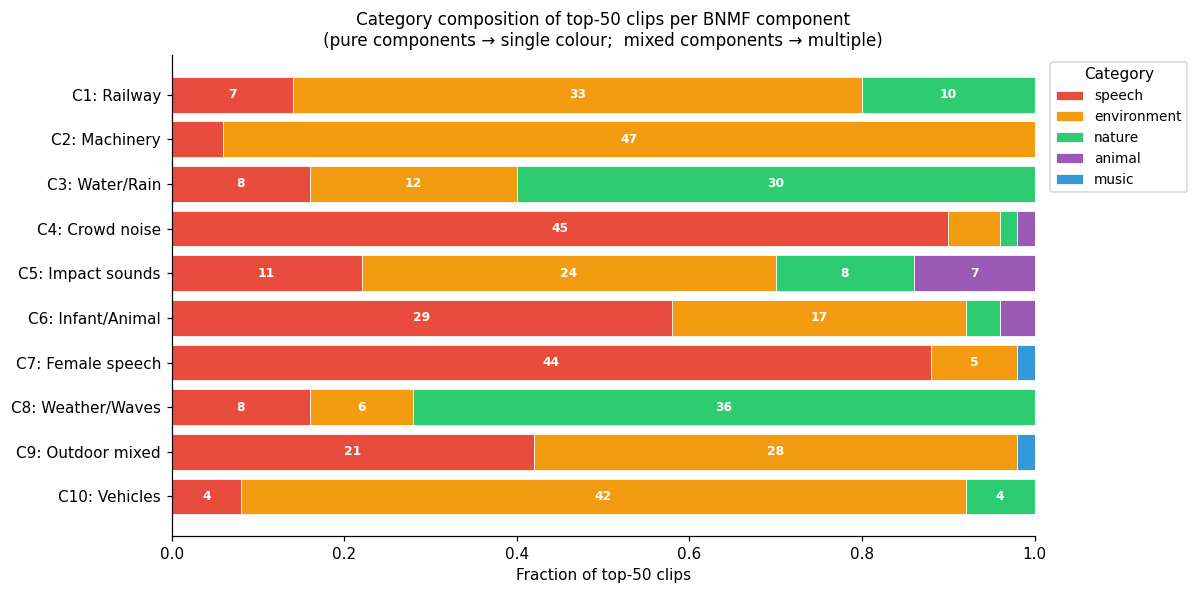

In [4]:
TOP_N = 50
comp_cat_counts = np.zeros((K, len(ALL_CATS)), dtype=int)
for c in range(K):
    top_idx = np.argsort(cons_resp[:, c])[::-1][:TOP_N]
    for j, cat in enumerate(ALL_CATS):
        comp_cat_counts[c, j] = (labels_cat[top_idx] == cat).sum()

comp_cat_frac = comp_cat_counts / TOP_N

fig, ax = plt.subplots(figsize=(11, 5.5))
left = np.zeros(K)
y = np.arange(K)
for j, cat in enumerate(ALL_CATS):
    ax.barh(y, comp_cat_frac[:, j], left=left, color=CAT_COLORS[cat],
            label=cat, edgecolor="white", linewidth=0.5)
    for c in range(K):
        v = comp_cat_frac[c, j]
        if v >= 0.08:
            ax.text(left[c] + v / 2, c, f"{int(comp_cat_counts[c, j])}",
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")
    left += comp_cat_frac[:, j]

ax.set_yticks(y)
ax.set_yticklabels(COMP_NAMES)
ax.invert_yaxis()
ax.set_xlabel(f"Fraction of top-{TOP_N} clips")
ax.set_xlim(0, 1)
ax.set_title(f"Category composition of top-{TOP_N} clips per BNMF component\n"
             "(pure components → single colour;  mixed components → multiple)",
             fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, title="Category")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "stacked_category_composition.png", bbox_inches="tight")
plt.show()


## 4. Component co-activation correlation

If two components tend to be active on the same clips, they probably capture
overlapping concepts. We compute the Pearson correlation matrix of the
consensus activation vectors (each column of `cons_resp` is one component's
activation across all 1442 clips).


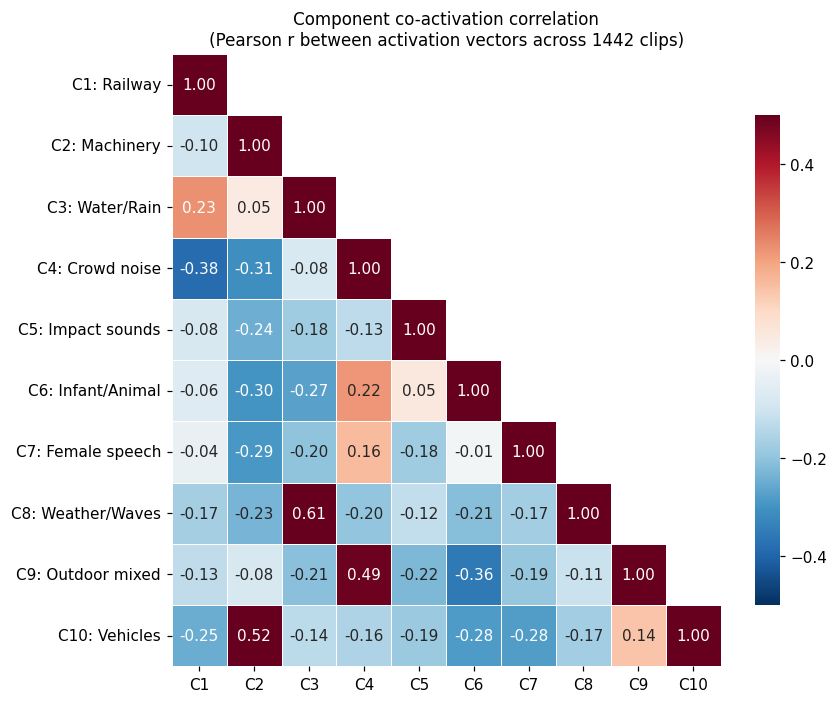

Top-5 most co-activated component pairs (r):
  C3: Water/Rain             ⟷  C8: Weather/Waves           r = +0.605
  C2: Machinery              ⟷  C10: Vehicles               r = +0.517
  C4: Crowd noise            ⟷  C9: Outdoor mixed           r = +0.491
  C1: Railway                ⟷  C3: Water/Rain              r = +0.230
  C4: Crowd noise            ⟷  C6: Infant/Animal           r = +0.220

Top-5 most distinct (negatively correlated) pairs:
  C2: Machinery              ⟷  C7: Female speech           r = -0.289
  C2: Machinery              ⟷  C6: Infant/Animal           r = -0.297
  C2: Machinery              ⟷  C4: Crowd noise             r = -0.309
  C6: Infant/Animal          ⟷  C9: Outdoor mixed           r = -0.356
  C1: Railway                ⟷  C4: Crowd noise             r = -0.384


In [5]:
act_corr = np.corrcoef(cons_resp.T)   # (K, K)

mask = np.triu(np.ones_like(act_corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(act_corr, annot=True, fmt=".2f",
            xticklabels=[f"C{i+1}" for i in range(K)],
            yticklabels=COMP_NAMES,
            cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            mask=mask, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Component co-activation correlation\n"
             "(Pearson r between activation vectors across 1442 clips)",
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "component_coactivation.png", bbox_inches="tight")
plt.show()

# Identify the strongest positive co-activations
upper = np.triu_indices(K, k=1)
pairs = sorted(zip(act_corr[upper], upper[0], upper[1]), key=lambda t: -t[0])
print("Top-5 most co-activated component pairs (r):")
for r, i, j in pairs[:5]:
    print(f"  {COMP_NAMES[i]:<25s}  ⟷  {COMP_NAMES[j]:<25s}   r = {r:+.3f}")
print("\nTop-5 most distinct (negatively correlated) pairs:")
for r, i, j in pairs[-5:]:
    print(f"  {COMP_NAMES[i]:<25s}  ⟷  {COMP_NAMES[j]:<25s}   r = {r:+.3f}")


## 5. Weight-space similarity

Each component is a vector in 768-d AST space (a row of `cons_weights`). Cosine
similarity between these rows tells us which components occupy nearby regions
of the embedding space — independent of which clips activate them.


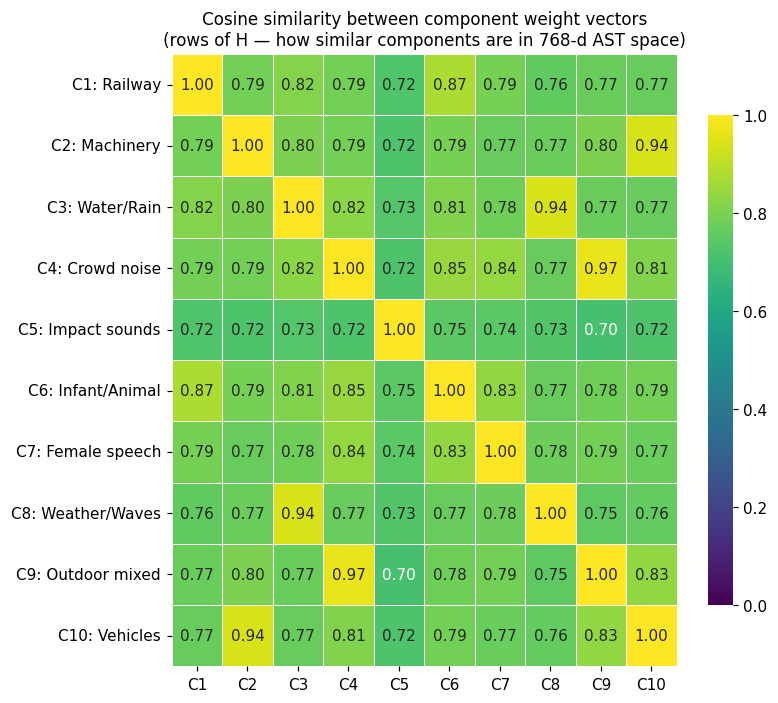

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

W_sim = cosine_similarity(cons_weights)   # (K, K)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(W_sim, annot=True, fmt=".2f",
            xticklabels=[f"C{i+1}" for i in range(K)],
            yticklabels=COMP_NAMES,
            cmap="viridis", vmin=0, vmax=1, linewidths=0.5,
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Cosine similarity between component weight vectors\n"
             "(rows of H — how similar components are in 768-d AST space)",
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "weight_space_similarity.png", bbox_inches="tight")
plt.show()


## 6. Top AST feature dimensions per component

The H matrix has shape `(K=10, 768)`. For each component, we keep the top 30 AST
dimensions by absolute weight. The resulting heatmap shows the "fingerprint"
each component uses to project into AST feature space.


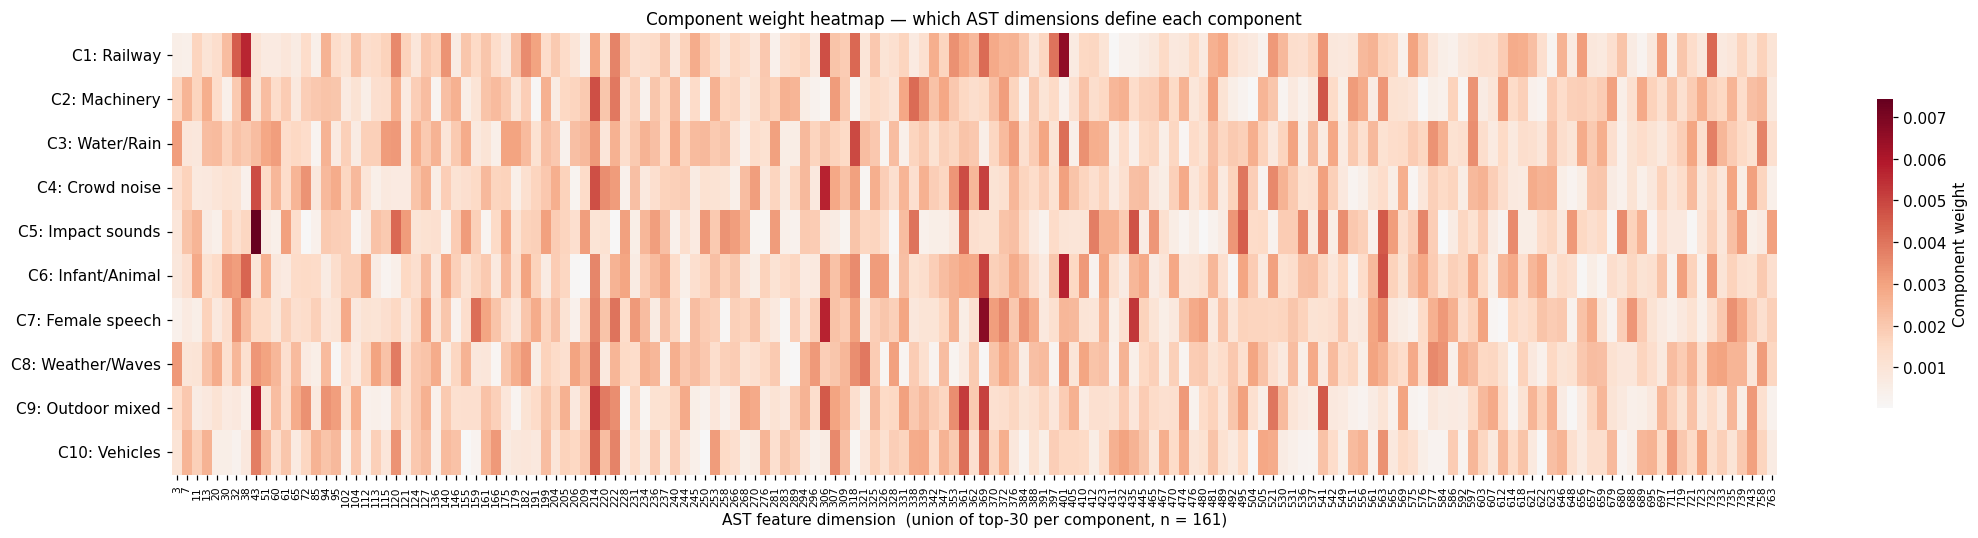

Total unique top-30 dimensions across all 10 components: 161
  → average overlap: 1.86x


In [7]:
TOP_DIMS = 30
top_dim_set = set()
for c in range(K):
    top_dim_set.update(np.argsort(np.abs(cons_weights[c]))[::-1][:TOP_DIMS])
sel_dims = sorted(top_dim_set)
W_sel = cons_weights[:, sel_dims]

fig, ax = plt.subplots(figsize=(min(20, 0.18 * len(sel_dims) + 4), 5))
sns.heatmap(W_sel,
            xticklabels=sel_dims,
            yticklabels=COMP_NAMES,
            cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Component weight", "shrink": 0.7})
ax.set_xlabel(f"AST feature dimension  (union of top-{TOP_DIMS} per component, "
              f"n = {len(sel_dims)})")
ax.set_title("Component weight heatmap — which AST dimensions define each component",
             fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "component_weight_heatmap.png", bbox_inches="tight")
plt.show()

print(f"Total unique top-{TOP_DIMS} dimensions across all {K} components: {len(sel_dims)}")
print(f"  → average overlap: {K * TOP_DIMS / len(sel_dims):.2f}x")


## 7. Component purity (category entropy)

A component is **pure** if its top-N clips come from a single ground-truth
category, and **mixed** otherwise. We quantify this with Shannon entropy of the
category distribution (lower entropy → purer). Normalised entropy = entropy /
log₂(5) so 0 = perfectly pure, 1 = uniform across 5 categories.


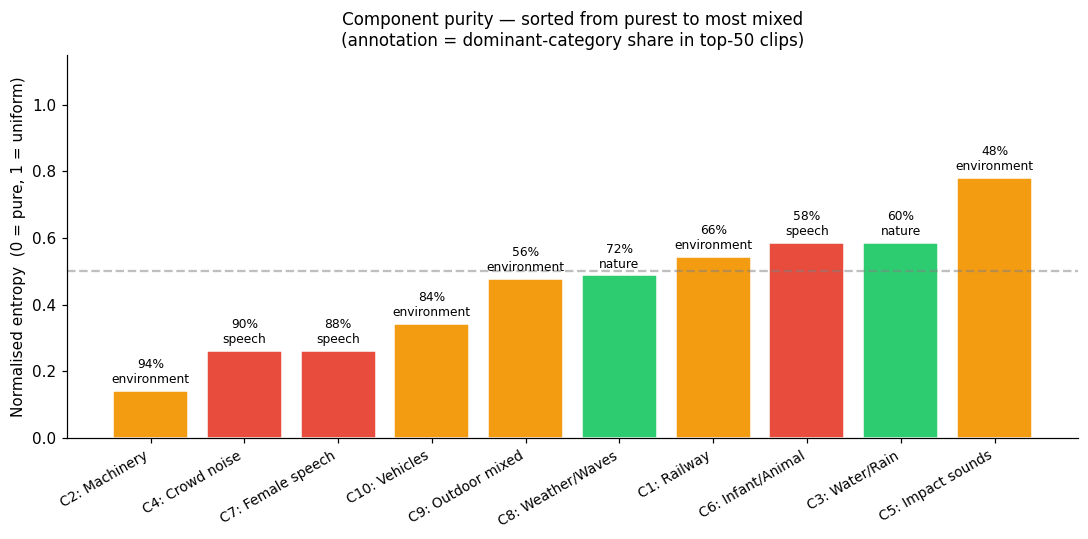

,component,dominant_category,dominant_fraction,normalised_entropy
0,C2: Machinery,environment,94.0%,0.141
1,C4: Crowd noise,speech,90.0%,0.261
2,C7: Female speech,speech,88.0%,0.262
3,C10: Vehicles,environment,84.0%,0.342
4,C9: Outdoor mixed,environment,56.0%,0.477
5,C8: Weather/Waves,nature,72.0%,0.487
6,C1: Railway,environment,66.0%,0.541
7,C6: Infant/Animal,speech,58.0%,0.584
8,C3: Water/Rain,nature,60.0%,0.585
9,C5: Impact sounds,environment,48.0%,0.779


In [8]:
H_norm = np.zeros(K)
dom_cat = []
dom_frac = []
for c in range(K):
    counts = comp_cat_counts[c]
    p = counts / counts.sum()
    H_norm[c] = scipy_entropy(p + 1e-12, base=2) / np.log2(len(ALL_CATS))
    j = int(np.argmax(counts))
    dom_cat.append(ALL_CATS[j])
    dom_frac.append(counts[j] / counts.sum())

order = np.argsort(H_norm)   # purest first

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [CAT_COLORS[dom_cat[i]] for i in order]
bars = ax.bar(np.arange(K), H_norm[order], color=bar_colors, edgecolor="white")
for i, b in enumerate(bars):
    c_i = order[i]
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015,
            f"{dom_frac[c_i]*100:.0f}%\n{dom_cat[c_i]}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(np.arange(K))
ax.set_xticklabels([COMP_NAMES[i] for i in order], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Normalised entropy  (0 = pure, 1 = uniform)")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Component purity — sorted from purest to most mixed\n"
             "(annotation = dominant-category share in top-50 clips)",
             fontsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "component_purity_entropy.png", bbox_inches="tight")
plt.show()

purity_df = pd.DataFrame({
    "component":           COMP_NAMES,
    "dominant_category":   dom_cat,
    "dominant_fraction":   [f"{x*100:.1f}%" for x in dom_frac],
    "normalised_entropy":  H_norm.round(3),
}).sort_values("normalised_entropy").reset_index(drop=True)
purity_df


## 8. Confusion matrix — dominant component vs true category

For each clip we identify which BNMF component is most strongly activated, and
compare that **unsupervised assignment** against the (weakly-labelled) ground
truth. This is the closest thing to "BNMF as a clustering algorithm".


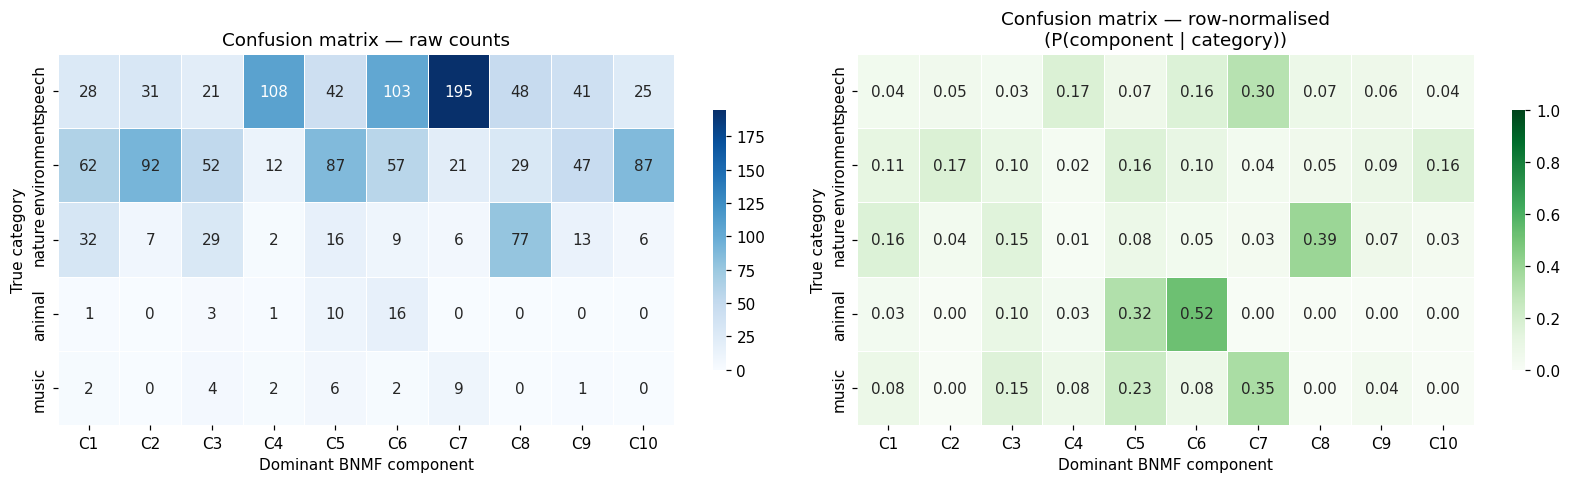

dominant component,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
true category,,,,,,,,,,
speech,28,31,21,108,42,103,195,48,41,25
environment,62,92,52,12,87,57,21,29,47,87
nature,32,7,29,2,16,9,6,77,13,6
animal,1,0,3,1,10,16,0,0,0,0
music,2,0,4,2,6,2,9,0,1,0


In [9]:
dom_comp = np.argmax(cons_resp, axis=1)
comp_for_clip = [f"C{c+1}" for c in dom_comp]

cm = pd.crosstab(pd.Series(labels_cat, name="true category"),
                 pd.Series(comp_for_clip, name="dominant component"))
cm = cm.reindex(index=ALL_CATS, columns=[f"C{i+1}" for i in range(K)], fill_value=0)
cm_norm = cm.div(cm.sum(axis=1), axis=0)   # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            cbar_kws={"shrink": 0.7}, linewidths=0.5, ax=axes[0])
axes[0].set_title("Confusion matrix — raw counts")
axes[0].set_xlabel("Dominant BNMF component")
axes[0].set_ylabel("True category")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            cbar_kws={"shrink": 0.7}, linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Confusion matrix — row-normalised\n(P(component | category))")
axes[1].set_xlabel("Dominant BNMF component")
axes[1].set_ylabel("True category")

plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_dominant_component.png", bbox_inches="tight")
plt.show()
cm


## 9. TF-IDF top words from top-captions per component

Treat each component's top-N captions as one "document" and the remaining
captions as the background. TF-IDF then highlights the words that are
characteristic of each component.


In [10]:
TOP_N_FOR_TFIDF = 30
docs = []
for c in range(K):
    top_idx = np.argsort(cons_resp[:, c])[::-1][:TOP_N_FOR_TFIDF]
    docs.append(" ".join(captions[top_idx]))

vec = TfidfVectorizer(stop_words="english", min_df=2, max_df=0.7,
                      token_pattern=r"[A-Za-z]{3,}")
X = vec.fit_transform(docs)
vocab = np.array(vec.get_feature_names_out())

TOP_W = 10
rows = []
for c in range(K):
    weights = X[c].toarray().flatten()
    top_w_idx = weights.argsort()[::-1][:TOP_W]
    words = [(vocab[i], weights[i]) for i in top_w_idx if weights[i] > 0]
    rows.append({"component": COMP_NAMES[c],
                 "top words": ", ".join(w for w, _ in words)})

pd.set_option("display.max_colwidth", 120)
top_words_df = pd.DataFrame(rows)
top_words_df


,component,top words
0,C1: Railway,"train, horn, railroad, running, tracks, water, passes, signal, blowing, blows"
1,C2: Machinery,"engine, revving, running, idle, car, vehicle, vibrating, motor, starting, times"
2,C3: Water/Rain,"rain, water, thunder, falling, splashing, gurgling, stream, falls, trickling, river"
3,C4: Crowd noise,"crowd, whistle, cheer, children, woman, talk, applauding, cheering, train, group"
4,C5: Impact sounds,"cat, meowing, door, speech, person, laughs, laughing, high, bell, occurs"
5,C6: Infant/Animal,"crying, baby, laughing, woman, young, cries, person, laugh, cawing, child"
6,C7: Female speech,"speaks, woman, female, adult, faucet, metal, water, environment, speech, dog"
7,C8: Weather/Waves,"rain, thunder, water, wind, heavy, stream, river, falls, flowing, splashing"
8,C9: Outdoor mixed,"train, horn, talk, honking, crowd, railroad, engine, truck, vehicle, blowing"
9,C10: Vehicles,"engine, revving, vehicle, accelerates, accelerating, car, revs, motor, running, humming"


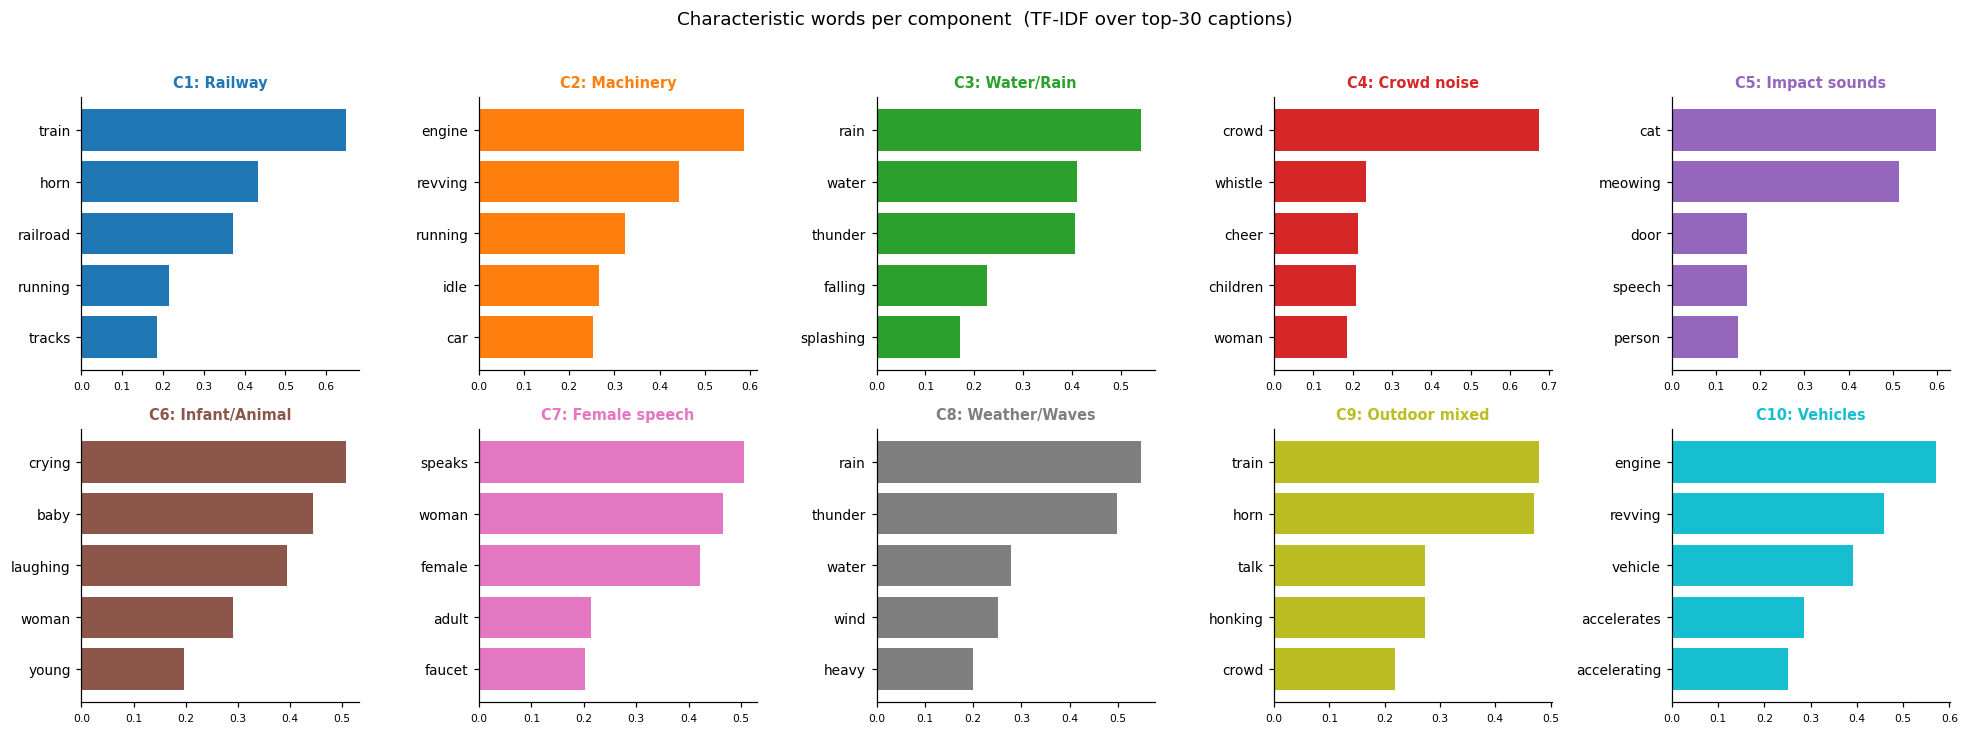

In [11]:
# Bar plot of top-5 words per component
fig, axes = plt.subplots(2, 5, figsize=(18, 6.5), sharex=False)
axes_flat = axes.flatten()
TOP_W_VIS = 5

for c in range(K):
    weights = X[c].toarray().flatten()
    top_w_idx = weights.argsort()[::-1][:TOP_W_VIS]
    words = [vocab[i] for i in top_w_idx]
    vals  = [weights[i] for i in top_w_idx]
    ax = axes_flat[c]
    ax.barh(range(len(words))[::-1], vals, color=BNMF_COLORS[c])
    ax.set_yticks(range(len(words))[::-1])
    ax.set_yticklabels(words, fontsize=9)
    ax.set_title(COMP_NAMES[c], fontsize=9.5, color=BNMF_COLORS[c], fontweight="bold")
    ax.tick_params(axis="x", labelsize=7)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle("Characteristic words per component  (TF-IDF over top-30 captions)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "tfidf_top_words.png", bbox_inches="tight")
plt.show()


## 10. t-SNE small multiples — activation **strength** per component

We project the 1442 clips into 2-D with t-SNE, then make K small panels, each
shaded by the activation strength of one component. This is more informative
than a single colour-by-dominant-component plot because it reveals partial /
overlapping activations.


In [12]:
# Compute t-SNE on 50-d PCA of standardised AST features (matches main notebook).
TSNE_CACHE = BNMF_DIR / "tsne_2d.npy"

if TSNE_CACHE.exists():
    tsne_2d = np.load(TSNE_CACHE)
    print(f"Loaded cached t-SNE from {TSNE_CACHE.name}")
else:
    print("Computing t-SNE (≈1 min)...")
    ast_sc  = StandardScaler().fit_transform(ast_feats)
    ast_50  = PCA(n_components=50, random_state=42).fit_transform(ast_sc)
    tsne_2d = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42).fit_transform(ast_50)
    np.save(TSNE_CACHE, tsne_2d)
    print(f"Cached t-SNE to {TSNE_CACHE.name}")

print(f"t-SNE coords shape: {tsne_2d.shape}")


Computing t-SNE (≈1 min)...


Cached t-SNE to tsne_2d.npy
t-SNE coords shape: (1442, 2)


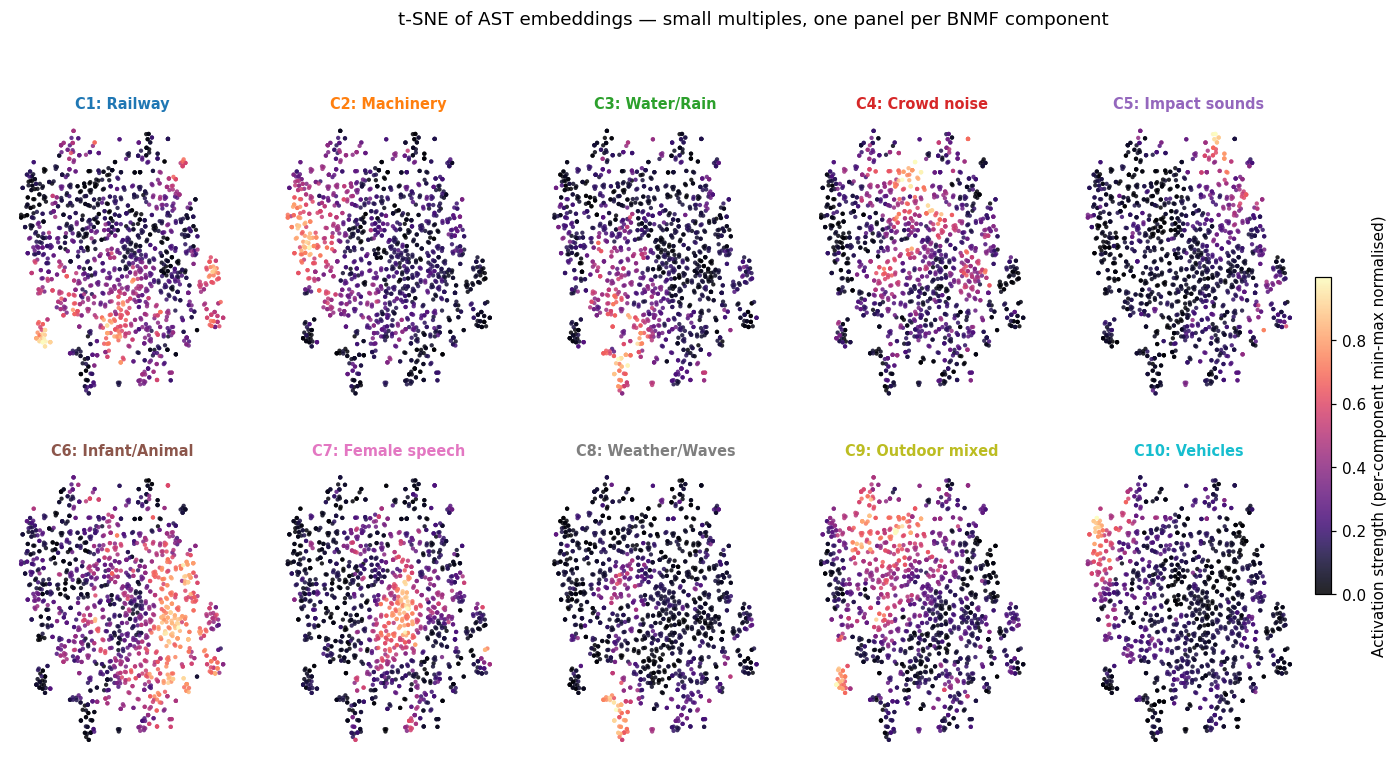

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

for c in range(K):
    ax = axes_flat[c]
    act = cons_resp[:, c]
    # Normalise per-component for visual comparison
    a_norm = (act - act.min()) / (act.max() - act.min() + 1e-12)
    order = np.argsort(a_norm)
    sc = ax.scatter(tsne_2d[order, 0], tsne_2d[order, 1],
                    c=a_norm[order], cmap="magma",
                    s=8, edgecolors="none", alpha=0.85)
    ax.set_title(COMP_NAMES[c], fontsize=9.5, color=BNMF_COLORS[c], fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

fig.colorbar(sc, ax=axes, shrink=0.5, pad=0.01,
             label="Activation strength (per-component min-max normalised)")
plt.suptitle("t-SNE of AST embeddings — small multiples, one panel per BNMF component",
             fontsize=12, y=1.01)
plt.savefig(FIG_DIR / "tsne_small_multiples.png", bbox_inches="tight")
plt.show()


## 11. Per-component activation strip plot — top-100 clips

For each component, sort clips by activation and plot the top 100 as a strip,
coloured by their true category. Sharp colour bands on the left side indicate a
component that activates almost exclusively on one category.


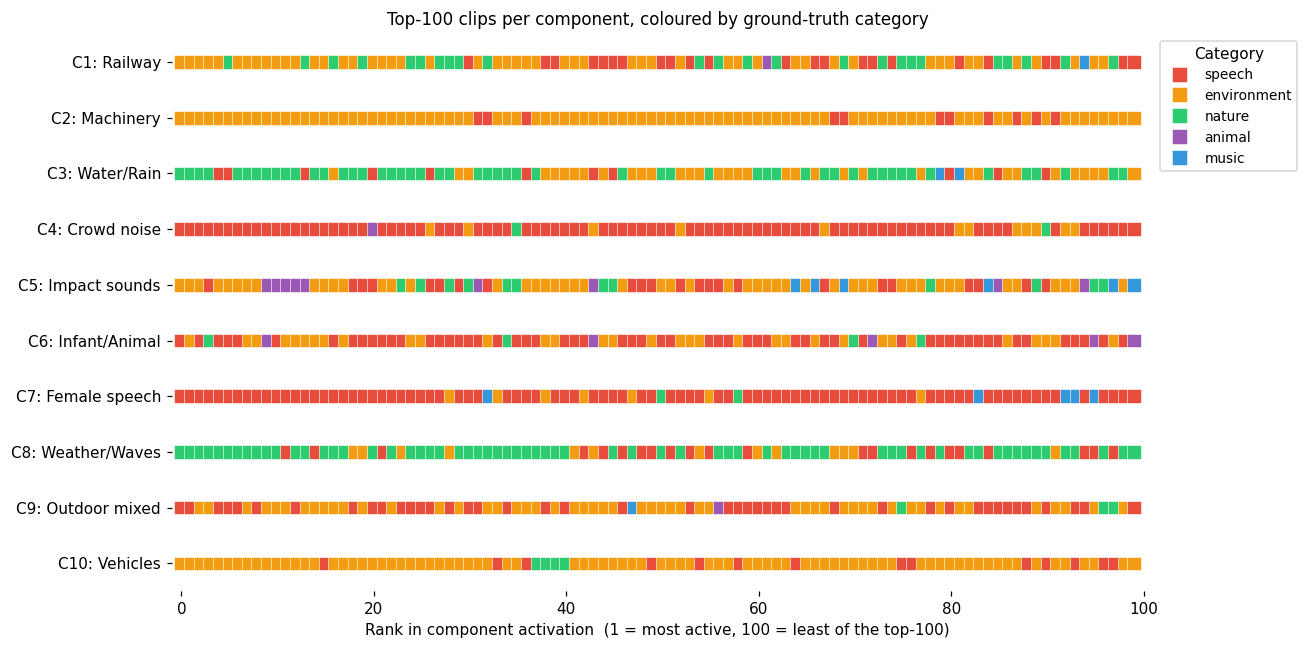

In [14]:
TOP_STRIP = 100
fig, ax = plt.subplots(figsize=(12, 0.45 * K + 1.5))

for c in range(K):
    order  = np.argsort(cons_resp[:, c])[::-1][:TOP_STRIP]
    cats_o = labels_cat[order]
    colors = [CAT_COLORS[cat] for cat in cats_o]
    ax.scatter(np.arange(TOP_STRIP), np.full(TOP_STRIP, c),
               c=colors, s=80, marker="s", edgecolors="white", linewidths=0.4)

ax.set_yticks(np.arange(K))
ax.set_yticklabels(COMP_NAMES)
ax.invert_yaxis()
ax.set_xlabel(f"Rank in component activation  (1 = most active, {TOP_STRIP} = least of the top-{TOP_STRIP})")
ax.set_title("Top-100 clips per component, coloured by ground-truth category",
             fontsize=11)
ax.set_xlim(-1, TOP_STRIP)
ax.set_ylim(K - 0.5, -0.5)
for s in ax.spines.values():
    s.set_visible(False)

handles = [plt.Line2D([0], [0], marker="s", color="w",
                      markerfacecolor=CAT_COLORS[c], markersize=10, label=c)
           for c in ALL_CATS]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=9, title="Category")
plt.tight_layout()
plt.savefig(FIG_DIR / "activation_strip_top100.png", bbox_inches="tight")
plt.show()


## 12. Summary

Pulling everything together, the BNMF decomposition discovers **10 sound
components** that:

* **Subdivide `environment`** into four meaningfully distinct sub-types
  (Railway, Machinery, Impact, Vehicles) — a level of structure that the
  5-category labels collapse into one bucket.
* **Subdivide `speech`** into clean female speech (C7), crowd / children noise
  (C4), and infant/animal vocalisations (C6).
* **Subdivide `nature`** into Water/Rain (C3) and Weather/Waves (C8).
* Leave a few **mixed components** (C5 Impact, C9 Outdoor mixed) whose top
  clips come from multiple ground-truth labels — these capture cross-category
  acoustic regularities the AST model has learned.

The co-activation matrix and weight-space cosine similarity show that pure
speech (C7) and crowd noise (C4) cluster together in AST space, as do the two
nature components (C3, C8) and the three vehicle/machinery components
(C1, C2, C10) — matching what we'd expect from acoustic similarity.

All figures are saved under `results/figures/extra/`.


In [15]:
# Persist the summary table for the report
purity_df.to_csv(BNMF_DIR / "component_purity.csv", index=False)
top_words_df.to_csv(BNMF_DIR / "component_top_words.csv", index=False)
print("Saved purity and top-words tables to results/bnmf/")


Saved purity and top-words tables to results/bnmf/
